In [4]:
import nltk
from nltk.corpus import treebank
import statistics
import matplotlib.pyplot as plt
import numpy as np
import re

# Download and load corpus
nltk.download('treebank')
sentences = treebank.sents()
words = treebank.words()
tagged_words = treebank.tagged_words()

# Remove trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# Cleaned sentences as strings
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Remove outliers based on sentence length ---
sentence_lengths = [len(sentence.split()) for sentence in cleaned_sentences]
Q1 = np.percentile(sentence_lengths, 25)
Q3 = np.percentile(sentence_lengths, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_cleaned_sentences = [
    sentence for sentence in cleaned_sentences
    if lower_bound <= len(sentence.split()) <= upper_bound
]

# Gather statistics on the filtered cleaned data
filtered_total_sentences = len(filtered_cleaned_sentences)
filtered_all_tokens = [token for sentence in filtered_cleaned_sentences for token in sentence.split()]
filtered_total_tokens = len(filtered_all_tokens)
filtered_unique_tokens = set(filtered_all_tokens)
filtered_total_unique_tokens = len(filtered_unique_tokens)

# Sentence length statistics
filtered_sentence_lengths = [len(sentence.split()) for sentence in filtered_cleaned_sentences]
if len(filtered_sentence_lengths) > 1:
    filtered_variance_sentence_length = round(statistics.pvariance(filtered_sentence_lengths), 3)
    filtered_std_dev_sentence_length = round(statistics.stdev(filtered_sentence_lengths), 3)
else:
    filtered_variance_sentence_length = 0
    filtered_std_dev_sentence_length = 0

# Average sentence length
filtered_average_sentence_length = round(filtered_total_tokens / filtered_total_sentences if filtered_total_sentences else 0, 3)

print(f"Original sentences: {len(cleaned_sentences)}")
print("\n--- Statistics for Filtered Cleaned Data ---")
print("Total number of sentences:", filtered_total_sentences)
print("Total number of words:", filtered_total_tokens)
print("Total number of unique words:", filtered_total_unique_tokens)
print("Average sentence length:", filtered_average_sentence_length)
print("Variance of sentence lengths:", filtered_variance_sentence_length)
print("Standard deviation of sentence lengths:", filtered_std_dev_sentence_length)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


Original sentences: 3914

--- Statistics for Filtered Cleaned Data ---
Total number of sentences: 3868
Total number of words: 90895
Total number of unique words: 11647
Average sentence length: 23.499
Variance of sentence lengths: 106.825
Standard deviation of sentence lengths: 10.337


In [ ]:
print(filtered_cleaned_sentences[0])

In [5]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    # Determine optimal device for Apple Silicon
    device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Set model to device and evaluation mode only once
    model.to(device)
    model.eval()
    
    # Preallocate output array for better memory efficiency
    embeddings = np.zeros((len(texts), model.config.hidden_size), dtype=np.float32)
    
    with torch.no_grad():  # Disable gradient calculation for inference
        # Process texts in small batches for better memory management
        batch_size = 32
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            batch_embeddings = []
            
            # Process each text individually to match original behavior
            for j, text in enumerate(batch_texts):
                # Keep padding=False to match original exactly
                inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
                outputs = model(**inputs)
                emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                batch_embeddings.append(emb[0])
                
                # Free memory for individual processing
                del inputs, outputs
            
            # Update embeddings array
            embeddings[i:i+len(batch_texts)] = np.array(batch_embeddings)
            
            # Free memory explicitly after batch
            del batch_embeddings
            if device == 'mps' or device == 'cuda':
                torch.mps.empty_cache() if device == 'mps' else torch.cuda.empty_cache()
                
    return embeddings


print("Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...")
X_sentence_features = get_bert_embeddings_no_padding(filtered_cleaned_sentences)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

get_bert_embeddings_no_padding([filtered_cleaned_sentences[0]])

Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...
Sentence BERT embeddings shape: (3868, 768)


array([[-4.86198276e-01,  2.93048412e-01,  3.75086993e-01,
        -3.84702384e-01, -1.77396685e-01, -5.29885292e-01,
         2.53705710e-01,  1.26502588e-01,  2.33976215e-01,
        -3.91963989e-01, -5.74748039e-01,  2.37874240e-02,
        -4.53744009e-02,  3.44385266e-01,  1.59705445e-01,
        -6.53184354e-02, -2.21710816e-01,  5.44918716e-01,
         2.04050243e-01, -3.10351998e-01, -2.53553241e-01,
        -6.99147046e-01,  6.85002208e-01,  8.21404979e-02,
        -1.12280577e-01, -2.87439346e-01, -1.02868676e-01,
        -3.81908268e-01, -4.05884564e-01, -5.37281573e-01,
         5.60068004e-02,  3.03228259e-01, -4.29823369e-01,
        -1.67788029e-01,  5.25796890e-01,  2.30641589e-01,
         5.94016373e-01, -3.33054066e-02,  2.52491176e-01,
         4.57178175e-01, -5.46683632e-02,  2.79393673e-01,
         5.22458196e-01, -4.93322819e-01, -1.40231624e-01,
        -5.15283465e-01, -2.63092327e+00, -1.74056724e-01,
        -1.22571692e-01, -1.94148242e-01,  1.66194677e-0

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
    median_absolute_error
)
import numpy as np

# Target: sentence lengths
y = [len(sentence.split()) for sentence in filtered_cleaned_sentences]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluate the model with multiple metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print(f"Test MSE: {mse:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")
print(f"Test Median AE: {medae:.3f}")
print(f"Test Max Error: {max_err:.3f}")
print(f"Test R^2: {r2:.3f}")
print(f"Test Explained Variance: {explained_var:.3f}")

Test MSE: 18.289
Test RMSE: 4.277
Test MAE: 3.302
Test Median AE: 2.635
Test Max Error: 17.890
Test R^2: 0.837
Test Explained Variance: 0.838


In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# 5-fold cross-validation for Linear Regression
lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = -cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='neg_mean_squared_error')
mae_scores = -cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='r2')
rmse_scores = np.sqrt(mse_scores)

print(f"Cross-validated MSE: {mse_scores.mean():.3f}")
print(f"Cross-validated RMSE: {rmse_scores.mean():.3f}")
print(f"Cross-validated MAE: {mae_scores.mean():.3f}")
print(f"Cross-validated R^2: {r2_scores.mean():.3f}")

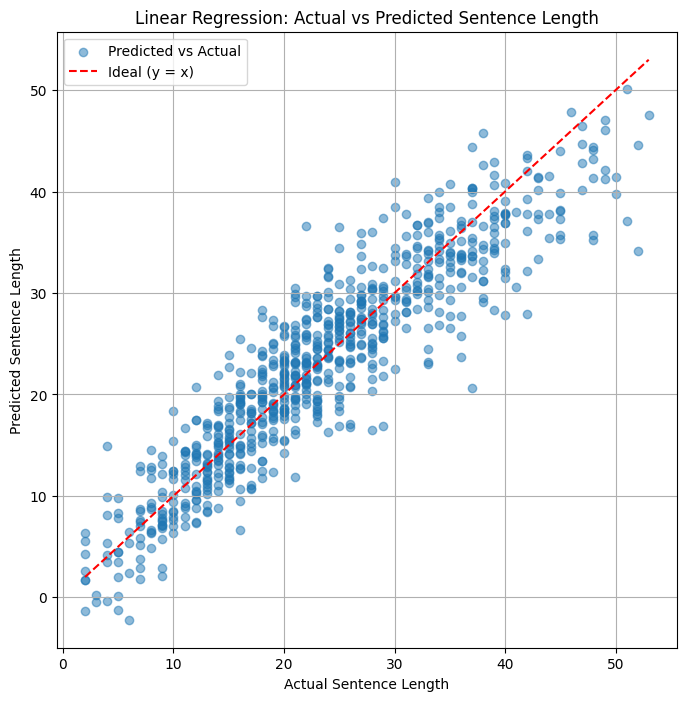

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal (y = x)")
plt.xlabel("Actual Sentence Length")
plt.ylabel("Predicted Sentence Length")
plt.title("Linear Regression: Actual vs Predicted Sentence Length")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split

            
X_train_sent, X_test_sentences, y_train_lengths, y_test_lengths, train_indices, test_indices = train_test_split(
    filtered_cleaned_sentences, y, list(range(len(filtered_cleaned_sentences))),
    test_size=0.2, random_state=42, shuffle=True, stratify=None
)

def show_sentence(idx):
    sent = X_test_sentences[idx]
    actual = y_test_lengths[idx]
    pred = y_pred[idx]
    display(Markdown(
        f"**Sentence:**<br>{sent}<br><br>"
        f"**Actual Length:** {actual}<br>"
        f"**Predicted Length:** {pred:.2f}"
    ))

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(X_test_sentences)-1,
    step=1,
    description='Test idx:',
    continuous_update=False
)

widgets.interact(show_sentence, idx=slider)

| Index | Tokens Sentence 10 | Tokens Sentence 18      | Tokens Sentence 370      | Tokens Sentence 545                                                                                   |
|-------|--------------------|------------------------|--------------------------|------------------------------------------------------------------------------------------------------|
| 1     | In                 | That                   | The                      | Campbell                                                                                            |
| 2     | 1973               | has                    | Transportation           | Soup                                                                                                |
| 3     | ,                  | been                   | Department               | ,                                                                                                   |
| 4     | Wells              | particularly           | ,                        | for                                                                                                 |
| 5     | Fargo              | true                   | responding               | one                                                                                                 |
| 6     | &                  | this                   | to                       | ,                                                                                                   |
| 7     | Co.                | year                   | pressure                 | is                                                                                                  |
| 8     | of                 | with                   | from                     | furious                                                                                             |
| 9     | San                | many                   | safety                   | its                                                                                                 |
| 10    | Francisco          | companies              | advocates                | Souper                                                                                              |
| 11    | launched           | raising                | ,                        | Combo                                                                                               |
| 12    | the                | their                  | took                     | microwave                                                                                           |
| 13    | Gold               | payouts                | further                  | product                                                                                             |
| 14    | Account            | more                   | steps                    | was                                                                                                 |
| 15    | ,                  | than                   | to                       | chastised                                                                                           |
| 16    | which              | 10                     | impose                   | in                                                                                                  |
| 17    | included           | %                      | on                       | the                                                                                                |
| 18    | free               | .                      | light                    | premiere                                                                                            |
| 19    | checking           |                        | trucks                   | ``                                                                                                  |
| 20    | ,                  |                        | and                      | In                                                                                                  |
| 21    | a                  |                        | vans                     | the                                                                                                |
| 22    | credit             |                        | the                      | Dumpster                                                                                            |
| 23    | card               |                        | safety                   | ''                                                                                                  |
| 24    | ,                  |                        | requirements             | column                                                                                              |
| 25    | safe-deposit       |                        | used                     | .                                                                                                   |
| 26    | box                |                        | for                      |                                                                                                     |
| 27    | and                |                        | automobiles              |                                                                                                     |
| 28    | travelers          |                        | .                        |                                                                                                     |
| 29    | checks             |                        |                          |                                                                                                     |
| 30    | for                |                        |                          |                                                                                                     |
| 31    | a                  |                        |                          |                                                                                                     |
| 32    | $                  |                        |                          |                                                                                                     |
| 33    | 3                  |                        |                          |                                                                                                     |
| 34    | monthly            |                        |                          |                                                                                                     |
| 35    | fee                |                        |                          |                                                                                                     |
| 36    | .                  |                        |                          |                                                                                                     |

Norm Entropy Min: 200.990
Norm Entropy Max: 278.827
Norm Entropy Mean: 252.696


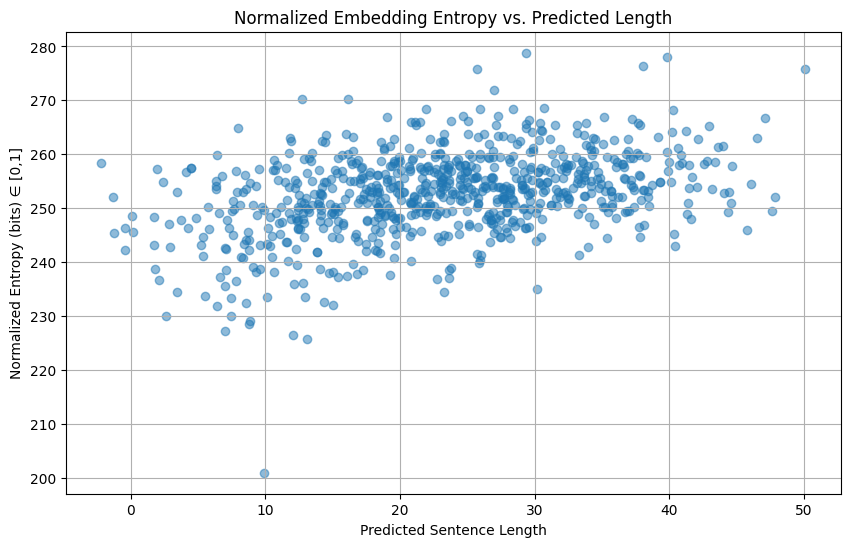

In [18]:


import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define entropy‐in‐bits function
def calculate_entropy_bits(embeddings):
    """
    embeddings: numpy array of shape (N, D)
    Returns: array of length N with entropy in bits
    """
    eps = 1e-12
    entropies = []
    for probs in embeddings:
        # softmax
        # v = vec - np.max(vec)
        # exp_v = np.exp(v)
        # probs = exp_v / np.sum(exp_v)
        # probs = probs + eps
        # probs = probs / np.sum(probs)
        # entropy in bits
        probs = np.abs(probs)
        probs = probs + 0.01
        H = -np.sum(probs * np.log2(probs))
        entropies.append(H)
    return np.array(entropies)

# Step 2: Compute raw entropies on your test embeddings X_test
raw_entropies = calculate_entropy_bits(X_test)

# Step 3: Normalize into [0,1]
D = X_test.shape[1]          # embedding dimension, e.g. 768
max_H = np.log2(D)           # maximum entropy in bits
normalized_entropies = raw_entropies / max_H

print(f"Norm Entropy Min: {raw_entropies.min():.3f}")
print(f"Norm Entropy Max: {raw_entropies.max():.3f}")
print(f"Norm Entropy Mean: {raw_entropies.mean():.3f}")

# Step 4: Plot Entropy vs. Predicted Length
plt.figure(figsize=(10,6))
plt.scatter(y_pred, raw_entropies, alpha=0.5)
plt.xlabel("Predicted Sentence Length")
plt.ylabel("Normalized Entropy (bits) ∈ [0,1]")
plt.title("Normalized Embedding Entropy vs. Predicted Length")
plt.grid(True)
plt.show()

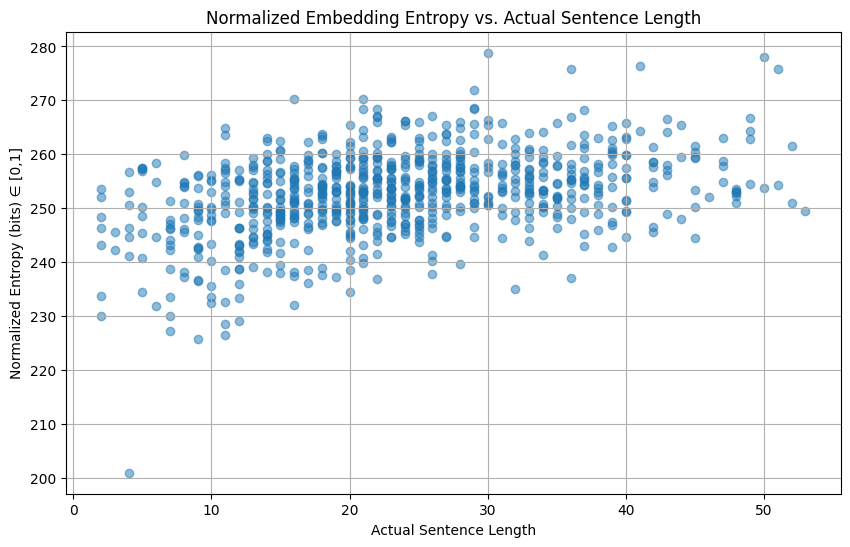

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, raw_entropies, alpha=0.5)
plt.xlabel("Actual Sentence Length")
plt.ylabel("Normalized Entropy (bits) ∈ [0,1]")
plt.title("Normalized Embedding Entropy vs. Actual Sentence Length")
plt.grid(True)
plt.show()


Sentence Length Entropy (nats): 3.720
Sentence Length Entropy (bits): 5.366

--- Entropy Comparison ---
Sentence Length Entropy (bits): 5.366
Mean Normalized Embedding Entropy: 0.965


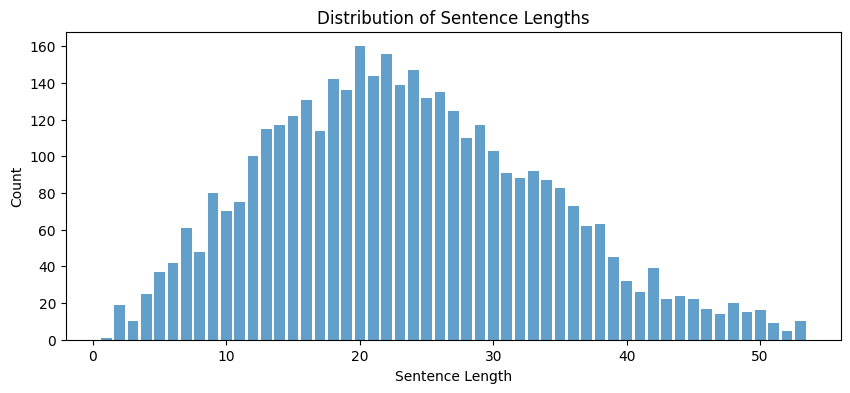

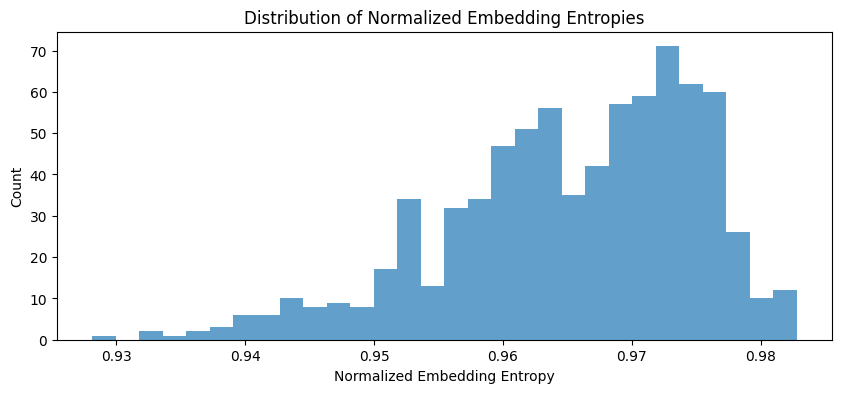

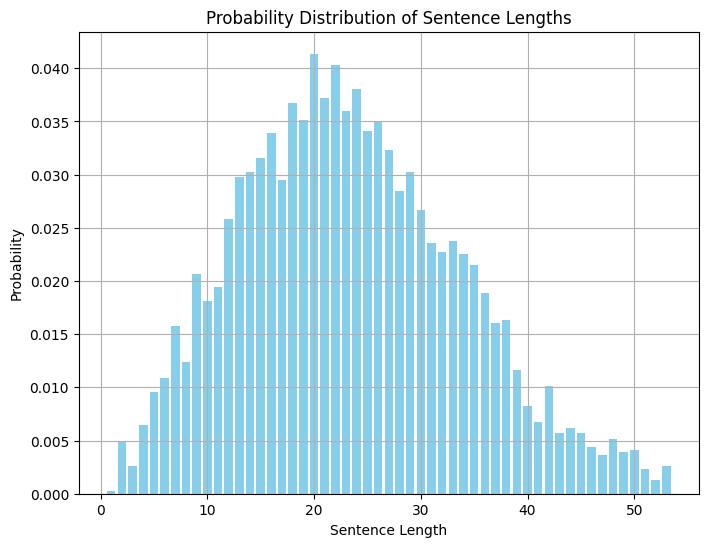

In [10]:
# --- Entropy of Sentence Length Distribution ---
from collections import Counter
from scipy.stats import entropy

# Calculate the probability distribution of sentence lengths
length_counts = Counter([len(sentence.split()) for sentence in filtered_cleaned_sentences])
total = sum(length_counts.values())
length_probs = np.array([count / total for count in length_counts.values()])

# Entropy in nats and bits
length_entropy_nats = entropy(length_probs)  # natural log
length_entropy_bits = entropy(length_probs, base=2)

print(f"Sentence Length Entropy (nats): {length_entropy_nats:.3f}")
print(f"Sentence Length Entropy (bits): {length_entropy_bits:.3f}")



print(f"\n--- Entropy Comparison ---")
print(f"Sentence Length Entropy (bits): {length_entropy_bits:.3f}")
print(f"Mean Normalized Embedding Entropy: {normalized_entropies.mean():.3f}")


import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(list(length_counts.keys()), list(length_counts.values()), alpha=0.7)
plt.xlabel('Sentence Length')
plt.ylabel('Count')
plt.title('Distribution of Sentence Lengths')
plt.show()


plt.figure(figsize=(10,4))
plt.hist(normalized_entropies, bins=30, alpha=0.7)
plt.xlabel('Normalized Embedding Entropy')
plt.ylabel('Count')
plt.title('Distribution of Normalized Embedding Entropies')
plt.show()


plt.figure(figsize=(8, 6))
plt.bar(length_counts.keys(), length_probs, color='skyblue')
plt.xlabel('Sentence Length')
plt.ylabel('Probability')
plt.title('Probability Distribution of Sentence Lengths')
plt.grid(True)
plt.show()

# ## Embedding Entropy is High

The normalized entropy of the BERT sentence embeddings is very high (mean ≈ 0.96–0.97, close to the theoretical maximum). This means the embeddings, when treated as pseudo-probability distributions, are highly "spread out" and unpredictable. In practical terms, the information in the embeddings is complex and not easily compressible or predictable.

## Sentence Length Entropy is Much Lower

The entropy of the sentence length distribution (in bits) is much lower than the normalized embedding entropy. This indicates that sentence length is much more "peaked" or concentrated—there are only a few likely sentence lengths, and most sentences fall into a narrow range. As a result, sentence length is much more predictable than the embedding features.

## Theory is Supported

The hypothesis was that sentence length has low entropy, making it easier for a model to predict compared to the high-entropy embedding features. The results confirm this: sentence length is indeed much easier to predict (lower entropy) than the embedding features (higher entropy). This is visually supported by the histogram of embedding entropies (clustered near 1) and the much lower value for sentence length entropy.

## Implications

Predicting sentence length from embeddings is a relatively "easy" task for a model, because the target variable (length) is much less random than the high-dimensional embedding space. This also means that high performance on sentence length prediction does not necessarily indicate that the embeddings are simple or uninformative—rather, the target itself is easy to guess.